# Model Comparison Study: Minimal Architecture for WISE Photometry Prediction

Systematically tests 17 models from complex (deep MLP) to simple (mean baseline) to find
the minimal architecture that reliably predicts WISE W1–W4 Vega magnitudes from SDSS
spectral latents (Jespersen et al. 2025 pre-computed features).

**Data source:** Jespersen et al. CSVs (764K galaxies), same as `train_their_data.py`.

**Chi definition:** `chi = (pred - obs) / sqrt(sigma_mag)` — matches demo notebook.

**Caching:** Set `FORCE_RETRAIN = True` to re-train all models; otherwise cached
predictions (`results/model_comparison/cache/{model_id}_preds.npy`) are reused.

---
## Section 0: Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
from pathlib import Path
from scipy.stats import norm as scipy_norm, pearsonr
from scipy.signal import medfilt
import time, sys

import torch
import torch.nn as nn
import torch.optim as optim

import joblib
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print(f"Python {sys.version.split()[0]}  |  NumPy {np.__version__}  |  PyTorch {torch.__version__}")
print("All imports OK")

Python 3.11.14  |  NumPy 2.4.2  |  PyTorch 2.4.0
All imports OK


In [2]:
# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Force-retrain flag ─────────────────────────────────────────────────────
# Set to True to ignore cached predictions and retrain everything from scratch.
FORCE_RETRAIN = True

# ─── Paths (relative to notebooks/ — notebook runs from there) ──────────────
DATA_DIR       = Path("../external/IR_optical_demo/data")
REG0_CSV       = DATA_DIR / "sdss_wise_cross_reg0.csv.gz"
REG1_CSV       = DATA_DIR / "sdss_wise_cross_reg1.csv.gz"
BASELINE_DIR   = Path("../results/their_data")    # existing mlp_baseline run
OUT_DIR        = Path("../results/model_comparison")
CACHE_DIR      = OUT_DIR / "cache"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ─── Hardware ───────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(4)

# ─── WISE band metadata ─────────────────────────────────────────────────────
WISE_BANDS   = ["W1", "W2", "W3", "W4"]
WISE_LABELS  = {"W1": r"WISE 3.4 $\mu$m",  "W2": r"WISE 4.6 $\mu$m",
                "W3": r"WISE 12.1 $\mu$m", "W4": r"WISE 22.2 $\mu$m"}
PAPER_CHI2   = {"W1": 1.33, "W2": 1.17, "W3": 2.23, "W4": 1.41}
NONDET_THR   = 5.0          # sigma threshold for non-detection
NONDET_SIGMA = 1e4          # sentinel sigma for non-detected bands in training

# ─── MLP training hyperparameters ───────────────────────────────────────────
LR       = 4e-3
N_EPOCHS = 500_000
PATIENCE = 1_000
VAL_EVERY = 10

print(f"Device:  {DEVICE}")
print(f"OUT_DIR: {OUT_DIR.resolve()}")
print(f"FORCE_RETRAIN: {FORCE_RETRAIN}")

Device:  cuda
OUT_DIR: /scratch/dmk333_new/Astronomy/results/model_comparison
FORCE_RETRAIN: True


---
## Section 1: Data Loading & Train/Test Split

In [3]:
for p in [REG0_CSV, REG1_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}")

df0 = pd.read_csv(REG0_CSV)
df1 = pd.read_csv(REG1_CSV)
df  = pd.concat([df0, df1], ignore_index=True)
N   = len(df)
print(f"reg0: {len(df0):,}  reg1: {len(df1):,}  total: {N:,}")

# ─── Features: spender latents (6D) + redshift + reg ────────────────────────
spender_cols = [f"spender_{i}" for i in range(6)]
feature_cols = spender_cols + ["Z", "reg"]
X_input = df[feature_cols].to_numpy(dtype=np.float32)
X_input = np.nan_to_num(X_input, nan=0.0, posinf=0.0, neginf=0.0)

# ─── Targets: WISE magnitudes + uncertainties ────────────────────────────────
mag_cols = ["w1mpro",    "w2mpro",    "w3mpro",    "w4mpro"]
sig_cols = ["w1sigmpro", "w2sigmpro", "w3sigmpro", "w4sigmpro"]

Y_mag_raw   = df[mag_cols].to_numpy(dtype=np.float32)
Y_sigma_raw = df[sig_cols].to_numpy(dtype=np.float32)
detected    = Y_sigma_raw < NONDET_THR

# Keep raw CSV magnitudes for non-detections — they contain real flux measurements
# at the source position (just with large sigma).  Do NOT replace with 0.0, which
# would introduce a systematic gradient pulling predictions toward unphysically
# bright magnitudes (0 Vega mag) for W3/W4 where non-detections are common.
Y_mag   = Y_mag_raw.copy().astype(np.float32)
Y_sigma = np.where(detected, Y_sigma_raw, NONDET_SIGMA).astype(np.float32)
Y_sigma = np.where((Y_sigma > 0) & np.isfinite(Y_sigma), Y_sigma, NONDET_SIGMA)

print(f"\nInput: {X_input.shape}   Targets: {Y_mag.shape}")
for j, b in enumerate(WISE_BANDS):
    nd = detected[:, j].sum()
    print(f"  {b}: {nd:,}/{N:,} detected ({100*nd/N:.1f}%)")

reg0: 252,139  reg1: 512,012  total: 764,151

Input: (764151, 8)   Targets: (764151, 4)
  W1: 764,151/764,151 detected (100.0%)
  W2: 763,999/764,151 detected (100.0%)
  W3: 559,162/764,151 detected (73.2%)
  W4: 272,183/764,151 detected (35.6%)


In [4]:
# ─── 80/20 split (SEED=42 — identical to train_their_data.py) ───────────────
ids = np.arange(N)
np.random.seed(SEED)
np.random.shuffle(ids)
n_train   = int(N * 0.8)
n_test    = N - n_train
idx_train = ids[:n_train]
idx_test  = ids[n_train:]

X_tr = X_input[idx_train]
X_te = X_input[idx_test]

Y_mag_tr    = Y_mag[idx_train]
Y_mag_te    = Y_mag[idx_test]
Y_sigma_tr  = Y_sigma[idx_train]
Y_sigma_te  = Y_sigma[idx_test]
Y_sigma_raw_te = Y_sigma_raw[idx_test]
det_te      = detected[idx_test]

# Combined [mag|sigma] tensor for GaussianNLL training (MLP models only)
Y_combined_tr = np.concatenate([Y_mag_tr, Y_sigma_tr], axis=1).astype(np.float32)
Y_combined_te = np.concatenate([Y_mag_te, Y_sigma_te], axis=1).astype(np.float32)

print(f"Train: {n_train:,}   Test: {n_test:,}")

# ─── Verify split matches existing baseline ──────────────────────────────────
baseline_npz = BASELINE_DIR / "test_results.npz"
if baseline_npz.exists():
    bl = np.load(baseline_npz)
    match = np.array_equal(bl["idx_test"], idx_test)
    print(f"Baseline idx_test match: {match}  (n_test={len(bl['idx_test']):,})")
    BASELINE_MATCHES = match
else:
    print("No baseline npz found — mlp_baseline will be trained from scratch.")
    BASELINE_MATCHES = False

Train: 611,320   Test: 152,831
Baseline idx_test match: True  (n_test=152,831)


---
## Section 2: Helper Functions

In [5]:
def compute_metrics(y_pred, y_true, sigma_raw, det_mask):
    """
    Compute per-band metrics.

    Parameters
    ----------
    y_pred   : (N_test, 4) predicted magnitudes
    y_true   : (N_test, 4) observed magnitudes
    sigma_raw: (N_test, 4) raw WISE sigmas (not capped)
    det_mask : (N_test, 4) bool, True = detected band

    Returns
    -------
    dict with keys: chi2n_demo, chi2n_std, iqr_chi, mean_chi,
                    r2, pearson_r, frac_outlier_3s, n_det   (per band)
    """
    results = {}
    for j, b in enumerate(WISE_BANDS):
        mask = det_mask[:, j] & (sigma_raw[:, j] < NONDET_THR)
        n_det = mask.sum()
        if n_det < 5:
            results[b] = {"n_det": n_det}
            continue
        resid     = y_pred[mask, j] - y_true[mask, j]
        sig       = sigma_raw[mask, j]
        chi_demo  = resid / np.sqrt(sig)
        chi_std   = resid / sig
        r2        = r2_score(y_true[mask, j], y_pred[mask, j])
        pr, _     = pearsonr(y_true[mask, j], y_pred[mask, j])
        results[b] = {
            "chi2n_demo"    : float(np.mean(chi_demo**2)),
            "chi2n_std"     : float(np.mean(chi_std**2)),
            "iqr_chi"       : float((np.percentile(chi_demo, 84) - np.percentile(chi_demo, 16)) / 2.0),
            "mean_chi"      : float(np.mean(chi_demo)),
            "r2"            : float(r2),
            "pearson_r"     : float(pr),
            "frac_outlier_3s": float(np.mean(np.abs(chi_demo) > 3)),
            "n_det"         : int(n_det),
        }
    return results


def print_metrics_table(metrics, model_name):
    print(f"\n{'='*65}")
    print(f"Model: {model_name}")
    print(f"{'='*65}")
    print(f"{'Band':<6s} {'chi2N_demo':>11s} {'chi2N_std':>10s} {'Paper':>7s} "
          f"{'IQR_chi':>8s} {'<chi>':>7s} {'R2':>7s} {'Pr':>7s} {'f_out3s':>8s} {'N_det':>8s}")
    print("-" * 85)
    for b in WISE_BANDS:
        m = metrics.get(b, {})
        if "chi2n_demo" not in m:
            print(f"{b:<6s} {'N/A':>11s}")
            continue
        print(f"{b:<6s} {m['chi2n_demo']:>11.3f} {m['chi2n_std']:>10.3f} "
              f"{PAPER_CHI2[b]:>7.2f} {m['iqr_chi']:>8.3f} {m['mean_chi']:>7.3f} "
              f"{m['r2']:>7.3f} {m['pearson_r']:>7.3f} {m['frac_outlier_3s']:>8.4f} "
              f"{m['n_det']:>8d}")


print("Metric functions defined.")

Metric functions defined.


In [ ]:
def IQR_sig(x):
    iqr = np.nanpercentile(x, [84, 16])
    return (iqr[0] - iqr[1]) / 2.0


def plot_chi_dist(y_pred, y_true, sigma_raw, det_mask, model_name, out_path):
    """2x2 chi-distribution histograms, one panel per WISE band."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for idx, b in enumerate(WISE_BANDS):
        ax      = axes[idx // 2, idx % 2]
        mask    = det_mask[:, idx] & (sigma_raw[:, idx] < NONDET_THR)
        if mask.sum() < 5:
            ax.text(0.5, 0.5, f"Too few {b} detections", transform=ax.transAxes, ha="center")
            ax.set_title(WISE_LABELS[b]); continue
        resid   = y_pred[mask, idx] - y_true[mask, idx]
        chi     = resid / np.sqrt(sigma_raw[mask, idx])
        chi2n   = np.mean(chi**2)
        iqr     = IQR_sig(chi)
        ax.hist(chi, bins=100, range=(-10, 10), histtype="step",
                density=True, color="steelblue", linewidth=1.5)
        x_      = np.linspace(-10, 10, 400)
        ax.plot(x_, scipy_norm.pdf(x_), "k--", lw=1.5, label=r"$\mathcal{N}(0,1)$")
        ax.set(xlim=(-10, 10),
               xlabel=r"$\chi = (\mathrm{pred}-\mathrm{obs})/\sqrt{\sigma}$",
               ylabel="Density", title=WISE_LABELS[b])
        ax.legend(fontsize=8)
        xt, yt, dy = 0.05, 0.82, 0.12
        f = {"size": 10}
        ax.text(xt, yt,      fr"$\chi^2_N$ = {chi2n:.2f}",  transform=ax.transAxes, fontdict=f)
        ax.text(xt, yt-dy,   fr"IQR: {iqr:.2f}",            transform=ax.transAxes, fontdict=f)
        ax.text(xt, yt-2*dy, fr"$\langle\chi\rangle$ = {np.mean(chi):.2f}",
                transform=ax.transAxes, fontdict=f)
    plt.suptitle(
        r"$\chi$-distribution  $[\chi = (\mathrm{pred}-\mathrm{obs})/\sqrt{\sigma}]$"
        f"\n{model_name}", fontsize=12, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_ppplot(y_pred, y_true, sigma_raw, det_mask, model_name, out_path):
    """2x2 PP-plot (probabilistic calibration), one panel per WISE band."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    for idx, b in enumerate(WISE_BANDS):
        ax      = axes[idx // 2, idx % 2]
        mask    = det_mask[:, idx] & (sigma_raw[:, idx] < NONDET_THR)
        if mask.sum() < 5:
            ax.text(0.5, 0.5, f"No {b} detections", transform=ax.transAxes, ha="center", va="center")
            ax.set_title(WISE_LABELS[b]); continue
        y_obs   = y_true[mask, idx]
        y_pr    = y_pred[mask, idx]
        sigma   = np.sqrt(sigma_raw[mask, idx])
        pe      = np.sort(scipy_norm.pdf(y_pr, loc=y_obs, scale=sigma))
        pd_     = np.sort(scipy_norm.pdf(0,    loc=0,     scale=sigma))
        thresh  = np.linspace(0, max(pe.max(), pd_.max()), 1000)
        cdf_e   = np.searchsorted(pe,  thresh) / len(pe)
        cdf_d   = np.searchsorted(pd_, thresh) / len(pd_)
        ax.plot([0, 1], [0, 1],  "r-",  lw=1.5,           label="Perfect calibration")
        ax.plot(cdf_d, cdf_d,    "k--", lw=1.5, alpha=0.7, label="Data baseline")
        ax.plot(cdf_d, cdf_e,    "g-",  lw=2.0,            label="This model")
        ax.set(xlabel="CDF(p̂_data)", ylabel="CDF(p̂_empirical)",
               title=WISE_LABELS[b], xlim=(0, 1), ylim=(0, 1), aspect="equal")
        ax.legend(loc="upper left", fontsize=8)
    plt.suptitle(
        f"PP-plot: probabilistic calibration\n{model_name}",
        fontsize=12, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_pred_vs_obs(y_pred, y_true, sigma_raw, det_mask, model_name, out_path):
    """2x2 predicted vs observed — detected sources only (scientifically rigorous)."""
    names = ["WISE 3.4 μm", "WISE 4.6 μm", "WISE 12.1 μm", "WISE 22.2 μm"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for j, b in enumerate(WISE_BANDS):
        ax      = axes[j // 2, j % 2]
        mask    = det_mask[:, j] & (sigma_raw[:, j] < NONDET_THR)
        if mask.sum() < 3:
            ax.text(0.5, 0.5, "—", transform=ax.transAxes, ha="center")
            ax.set_title(b); continue
        true    = y_true[mask, j]
        pred    = y_pred[mask, j]
        bias    = np.median(true - pred)
        scatter = (np.percentile(pred-true, 75) - np.percentile(pred-true, 25)) / 1.349
        tot     = np.hstack([true, pred])
        l       = 0.01
        lims    = np.percentile(tot, [l, 100-l])
        ax.hist2d(true, pred, bins=50, range=[lims, lims],
                  norm=matplotlib.colors.LogNorm(), cmap="viridis")
        ax.plot(lims, lims, "k--", lw=1, label="Perfect")
        ax.set(xlabel=f"Observed [{names[j]}]", ylabel=f"Predicted [{names[j]}]",
               title=names[j])
        f = {"size": 10}
        ax.text(0.03, 0.85, f"Bias: {bias:.2f} mag",  transform=ax.transAxes, fontdict=f)
        ax.text(0.03, 0.77, f"σ_IQR: {scatter:.2f}", transform=ax.transAxes, fontdict=f)
        ax.legend(loc="lower right", fontsize=8)
    plt.suptitle(f"Predicted vs Observed WISE magnitudes — detections only\n{model_name}",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_pred_vs_obs_all(y_pred, y_true, sigma_raw, det_mask, model_name, out_path):
    """2x2 predicted vs observed — all sources including non-detections (paper style).

    Non-detected sources have real flux measurements at the source position in the
    Jespersen et al. CSV (finite values, just with sigma=9999), so including them
    is physically meaningful and matches the style of Fig. 4 of Jespersen et al. 2025.
    """
    names = ["WISE 3.4 μm", "WISE 4.6 μm", "WISE 12.1 μm", "WISE 22.2 μm"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for j, b in enumerate(WISE_BANDS):
        ax    = axes[j // 2, j % 2]
        true  = y_true[:, j]
        pred  = y_pred[:, j]
        valid = np.isfinite(true) & np.isfinite(pred)
        true, pred = true[valid], pred[valid]
        if len(true) < 3:
            ax.text(0.5, 0.5, "—", transform=ax.transAxes, ha="center")
            ax.set_title(b); continue
        bias    = np.median(true - pred)
        scatter = (np.percentile(pred-true, 75) - np.percentile(pred-true, 25)) / 1.349
        tot     = np.hstack([true, pred])
        l       = 0.01
        lims    = np.percentile(tot, [l, 100-l])
        ax.hist2d(true, pred, bins=50, range=[lims, lims],
                  norm=matplotlib.colors.LogNorm(), cmap="viridis")
        ax.plot(lims, lims, "k--", lw=1, label="Perfect")
        ax.set(xlabel=f"Observed [{names[j]}]", ylabel=f"Predicted [{names[j]}]",
               title=names[j])
        f = {"size": 10}
        ax.text(0.03, 0.85, f"Bias: {bias:.2f} mag",  transform=ax.transAxes, fontdict=f)
        ax.text(0.03, 0.77, f"σ_IQR: {scatter:.2f}", transform=ax.transAxes, fontdict=f)
        n_nd = (~det_mask[:, j]).sum()
        ax.text(0.03, 0.69, f"incl. {n_nd:,} non-det.", transform=ax.transAxes, fontdict=f)
        ax.legend(loc="lower right", fontsize=8)
    plt.suptitle(
        f"Predicted vs Observed WISE magnitudes — all sources incl. non-detections\n"
        f"{model_name}  (cf. Fig. 4 of Jespersen et al. 2025)",
        fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


print("Plotting functions defined.")

In [7]:
def save_predictions(y_pred, model_id):
    np.save(CACHE_DIR / f"{model_id}_preds.npy", y_pred)


def load_predictions(model_id):
    p = CACHE_DIR / f"{model_id}_preds.npy"
    if p.exists():
        return np.load(p)
    return None


def make_model_dir(model_id):
    d = OUT_DIR / model_id
    d.mkdir(parents=True, exist_ok=True)
    return d


print("Cache helpers defined.")

Cache helpers defined.


In [ ]:
# ─── MLP builder (identical to train_their_data.py) ──────────────────────────
def build_mlp(n_in=8, hidden_layers=None, n_out=4):
    if hidden_layers is None:
        hidden_layers = [20, 50, 50, 20]
    layers = []
    prev = n_in
    for h in hidden_layers:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    layers.append(nn.Linear(prev, n_out))
    return nn.Sequential(*layers)


def build_linear_mlp(n_in=8, n_out=4):
    """Single linear layer (no hidden, no ReLU) — pure linear regression via MLP API."""
    return nn.Linear(n_in, n_out)


_nll = nn.GaussianNLLLoss(reduction='none')

def compute_loss(predictions, y_combined):
    """
    GaussianNLLLoss with var = sqrt(sigma_mag), restricted to detected bands only.

    Non-detected bands (sigma >= NONDET_THR) are excluded from the loss entirely,
    eliminating systematic gradient bias from fill values.
    """
    mags     = y_combined[:, :4]
    sigma    = y_combined[:, 4:]
    var      = torch.sqrt(sigma)
    det_mask = sigma < NONDET_THR                # (N, 4) bool: detected bands only
    loss_all = _nll(predictions, mags, var)      # (N, 4) per-element NLL
    return loss_all[det_mask].mean()


def train_mlp(X_tr_gpu, Y_tr_gpu, X_te_gpu, Y_te_gpu, hidden_layers, model_id,
              is_linear=False, force=False):
    """
    Train an MLP (or pure linear model) and return test-set predictions.
    Caches predictions to CACHE_DIR/{model_id}_preds.npy.
    If force=False and cache exists, loads directly.
    """
    cache_pred  = CACHE_DIR / f"{model_id}_preds.npy"
    cache_wt    = CACHE_DIR / f"{model_id}_weights.pt"
    cache_train = CACHE_DIR / f"{model_id}_train_loss.npy"

    if not force and not FORCE_RETRAIN and cache_pred.exists():
        print(f"[{model_id}] Loading cached predictions.")
        return np.load(cache_pred)

    print(f"[{model_id}] Training MLP hidden_layers={hidden_layers}  linear={is_linear}")
    torch.manual_seed(SEED)
    if is_linear:
        model = build_linear_mlp().to(DEVICE)
    else:
        model = build_mlp(hidden_layers=hidden_layers).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6,
        threshold=1e-6, threshold_mode="rel"
    )

    train_losses, test_losses = [], []
    min_test = float("inf")
    n_no_imp = 0
    best_state = None
    t0 = time.time()

    for epoch in range(N_EPOCHS):
        if n_no_imp >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break
        model.train()
        optimizer.zero_grad()
        loss = compute_loss(model(X_tr_gpu), Y_tr_gpu)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        if epoch % VAL_EVERY == 0:
            train_losses.append(loss.item())
            model.eval()
            with torch.no_grad():
                vl = compute_loss(model(X_te_gpu), Y_te_gpu).item()
            test_losses.append(vl)
            scheduler.step(vl)
            if vl < min_test * (1 - 1e-6):
                min_test = vl
                n_no_imp = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                n_no_imp += 1
            if (epoch // VAL_EVERY) % 200 == 0:
                lr_ = optimizer.param_groups[0]["lr"]
                print(f"  ep={epoch:>6d}  val={vl:.4f}  patience={n_no_imp}/{PATIENCE}  "
                      f"lr={lr_:.2e}  ({time.time()-t0:.0f}s)")

    if best_state:
        model.load_state_dict(best_state)

    print(f"  Done in {time.time()-t0:.1f}s  |  best val={min_test:.6f}")

    # ── Evaluate ──────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        y_pred = model(X_te_gpu).cpu().numpy()

    # ── Save curve ────────────────────────────────────────────────────────────
    x_ep  = np.arange(len(train_losses)) * VAL_EVERY
    smooth = min(21, len(train_losses) | 1)
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(x_ep, medfilt(train_losses, smooth), alpha=0.8, label="Train")
    ax.plot(x_ep, medfilt(test_losses,  smooth), alpha=0.8, label="Val")
    ax.set(yscale="log", xscale="log", xlim=(max(1, x_ep[1] if len(x_ep) > 1 else 1), None),
           title=f"{model_id} training curve", ylabel="Loss", xlabel="Epoch")
    ax.legend()
    plt.tight_layout()
    mdir = make_model_dir(model_id)
    plt.savefig(mdir / "training_curve.png", dpi=130, bbox_inches="tight")
    plt.show(); plt.close()

    # ── Cache ─────────────────────────────────────────────────────────────────
    np.save(cache_pred, y_pred)
    np.save(cache_train, np.array([train_losses, test_losses], dtype=object))
    torch.save(model.state_dict(), cache_wt)
    print(f"  Cached to {CACHE_DIR}")
    return y_pred


print("MLP training function defined.")

In [ ]:
def run_sklearn_model(model, X_tr, Y_tr, X_te, model_id, force=False):
    """
    Fit a scikit-learn model and return test-set predictions.
    Caches predictions and fitted model.
    """
    cache_pred  = CACHE_DIR / f"{model_id}_preds.npy"
    cache_model = CACHE_DIR / f"{model_id}_model.joblib"

    if not force and not FORCE_RETRAIN and cache_pred.exists():
        print(f"[{model_id}] Loading cached predictions.")
        return np.load(cache_pred)

    print(f"[{model_id}] Fitting {type(model).__name__} ...")
    t0 = time.time()
    model.fit(X_tr, Y_tr)
    y_pred = model.predict(X_te).astype(np.float32)
    print(f"  Done in {time.time()-t0:.1f}s")

    np.save(cache_pred, y_pred)
    joblib.dump(model, cache_model)
    print(f"  Cached to {CACHE_DIR}")
    return y_pred


def eval_and_plot(y_pred, model_id, model_name):
    """Compute metrics and save four plots: chi, PP, pred-vs-obs (det only), pred-vs-obs (all)."""
    mdir    = make_model_dir(model_id)
    metrics = compute_metrics(y_pred, Y_mag_te, Y_sigma_raw_te, det_te)
    print_metrics_table(metrics, model_name)
    plot_chi_dist(y_pred, Y_mag_te, Y_sigma_raw_te, det_te, model_name,
                  mdir / "chi_distribution.png")
    plot_ppplot(y_pred, Y_mag_te, Y_sigma_raw_te, det_te, model_name,
                mdir / "ppplot.png")
    plot_pred_vs_obs(y_pred, Y_mag_te, Y_sigma_raw_te, det_te, model_name,
                     mdir / "pred_vs_obs.png")
    plot_pred_vs_obs_all(y_pred, Y_mag_te, Y_sigma_raw_te, det_te, model_name,
                         mdir / "pred_vs_obs_all.png")
    return metrics


# Registry for summary table
ALL_METRICS  = {}   # model_id -> metrics dict
ALL_NAMES    = {}   # model_id -> display name

print("sklearn helper and registry defined.")

---
## Section 3: Feature Scaling

Fitted on training set only. Used for linear models and k-NN.
MLP and tree models receive unscaled inputs.

In [10]:
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr).astype(np.float32)
X_te_sc = scaler.transform(X_te).astype(np.float32)
print(f"Scaled X_tr: mean={X_tr_sc.mean():.4f}  std={X_tr_sc.std():.4f}")
print(f"Scaled X_te: mean={X_te_sc.mean():.4f}  std={X_te_sc.std():.4f}")

Scaled X_tr: mean=0.0000  std=1.0000
Scaled X_te: mean=0.0002  std=0.9976


---
## Section 4: GPU Tensor Preparation

In [11]:
X_tr_gpu = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
Y_tr_gpu = torch.tensor(Y_combined_tr, dtype=torch.float32).to(DEVICE)
X_te_gpu = torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
Y_te_gpu = torch.tensor(Y_combined_te, dtype=torch.float32).to(DEVICE)

print(f"GPU tensors: X_tr={tuple(X_tr_gpu.shape)}  Y_tr={tuple(Y_tr_gpu.shape)}")
print(f"             X_te={tuple(X_te_gpu.shape)}  Y_te={tuple(Y_te_gpu.shape)}")

GPU tensors: X_tr=(611320, 8)  Y_tr=(611320, 8)
             X_te=(152831, 8)  Y_te=(152831, 8)


---
## Section 5: Tier 1 — MLP Variants

All share Adam lr=4e-3, ReduceLROnPlateau, patience=1000, full-batch GaussianNLLLoss.

### 5.1  mlp_baseline  (8→20→50→50→20→4, 4,884 params)

[mlp_baseline] Training MLP hidden_layers=[20, 50, 50, 20]  linear=False
  Parameters: 4,884
  ep=     0  val=294.9189  patience=0/1000  lr=4.00e-03  (0s)
  ep=  2000  val=0.4064  patience=17/1000  lr=4.00e-03  (19s)
  ep=  4000  val=0.2180  patience=45/1000  lr=4.00e-03  (39s)
  ep=  6000  val=0.1800  patience=20/1000  lr=4.00e-03  (58s)
  ep=  8000  val=0.1584  patience=0/1000  lr=2.00e-03  (77s)
  ep= 10000  val=0.1532  patience=0/1000  lr=2.00e-03  (96s)
  ep= 12000  val=0.1533  patience=39/1000  lr=2.00e-03  (115s)
  ep= 14000  val=0.1519  patience=8/1000  lr=2.00e-03  (135s)
  ep= 16000  val=0.1520  patience=2/1000  lr=2.00e-03  (154s)
  ep= 18000  val=0.1491  patience=13/1000  lr=2.00e-03  (173s)
  ep= 20000  val=0.1525  patience=8/1000  lr=2.00e-03  (192s)
  ep= 22000  val=0.1469  patience=0/1000  lr=2.00e-03  (211s)
  ep= 24000  val=0.1485  patience=34/1000  lr=2.00e-03  (231s)
  ep= 26000  val=0.1461  patience=15/1000  lr=2.00e-03  (250s)
  ep= 28000  val=0.1480  patience=14/

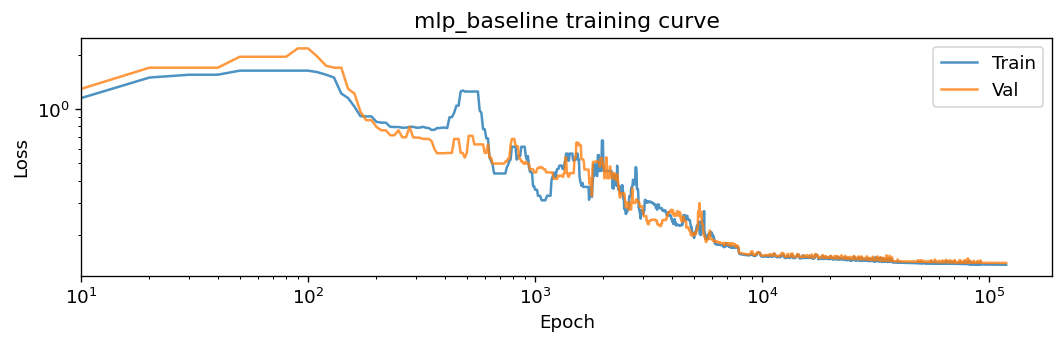

  Cached to ../results/model_comparison/cache

Model: MLP baseline (8→20→50→50→20→4)
Band    chi2N_demo  chi2N_std   Paper  IQR_chi   <chi>      R2      Pr  f_out3s    N_det
-------------------------------------------------------------------------------------
W1           1.539     54.408    1.33    1.079   0.008   0.913   0.956   0.0269   152831
W2           1.359     39.525    1.17    0.957   0.005   0.889   0.943   0.0209   152806
W3           2.558     63.413    2.23    1.196   0.005   0.806   0.901   0.0537   111738
W4           1.700     35.445    1.41    0.876   0.010   0.680   0.830   0.0285    54169


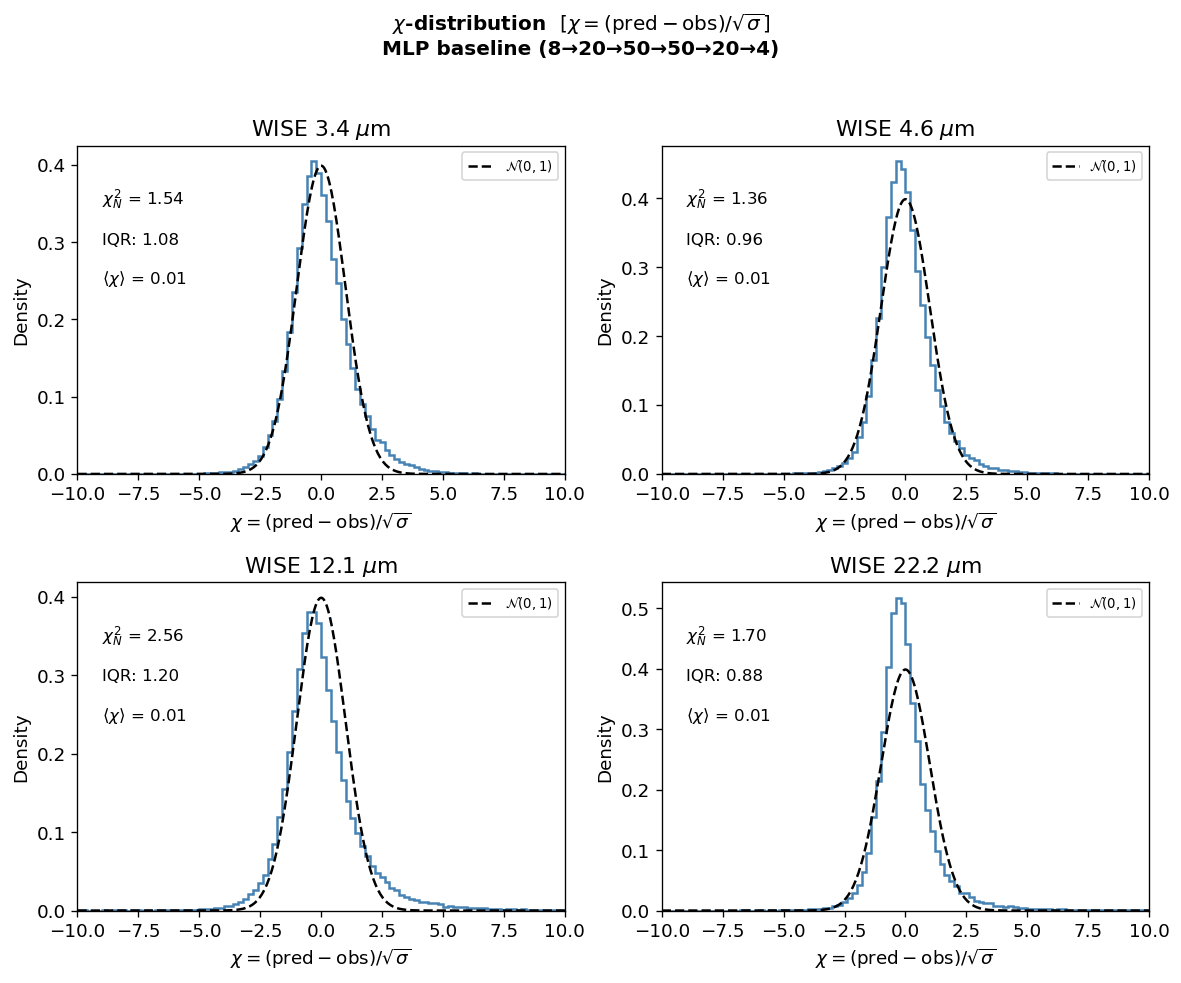

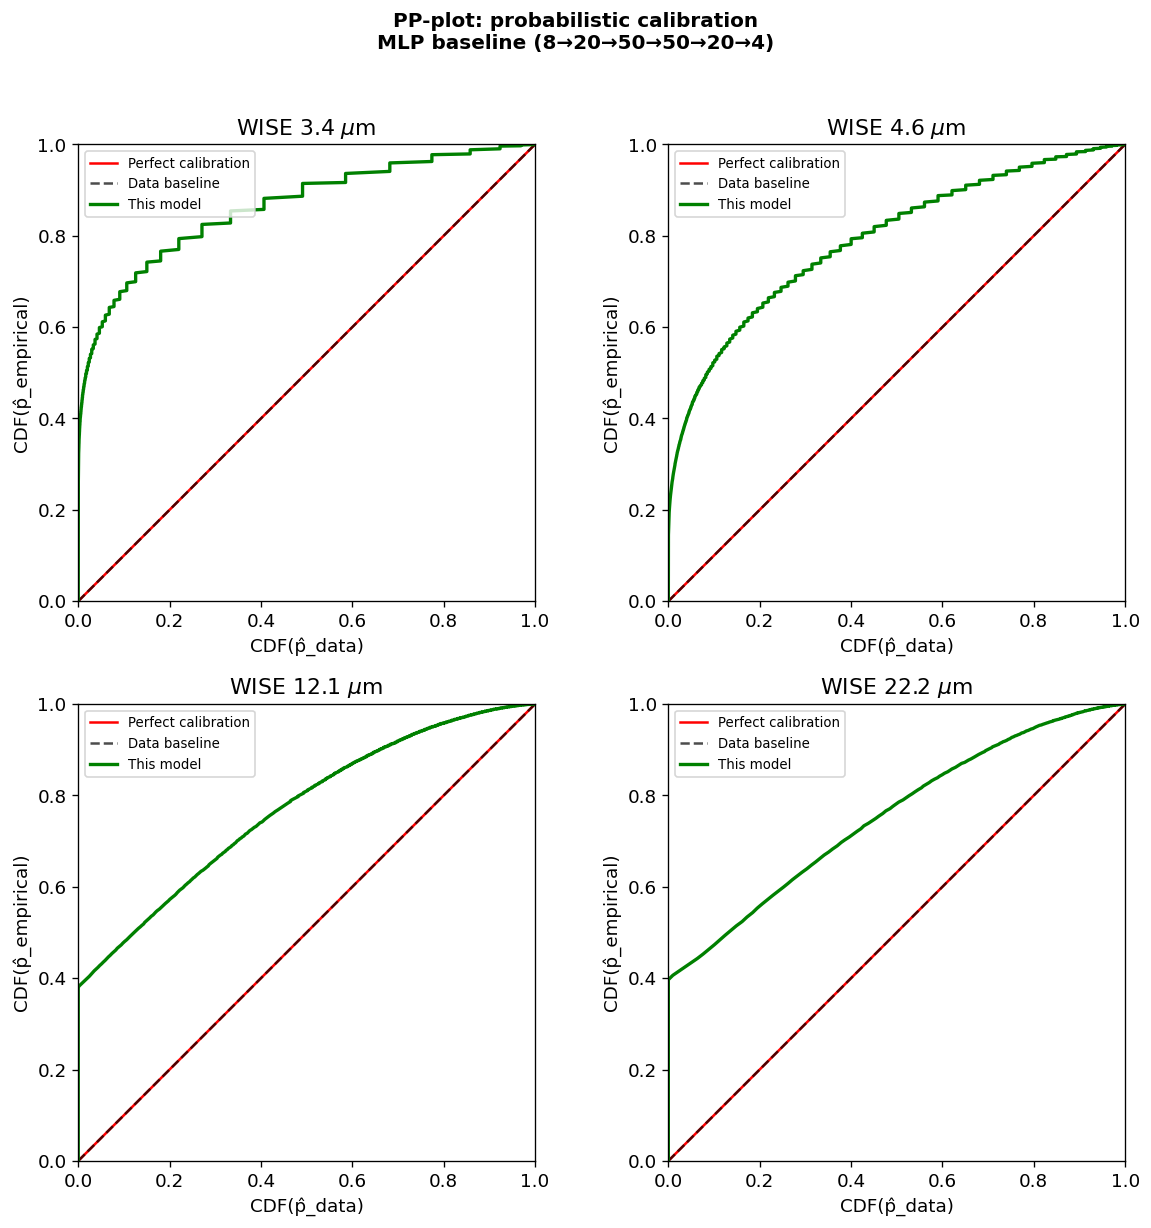

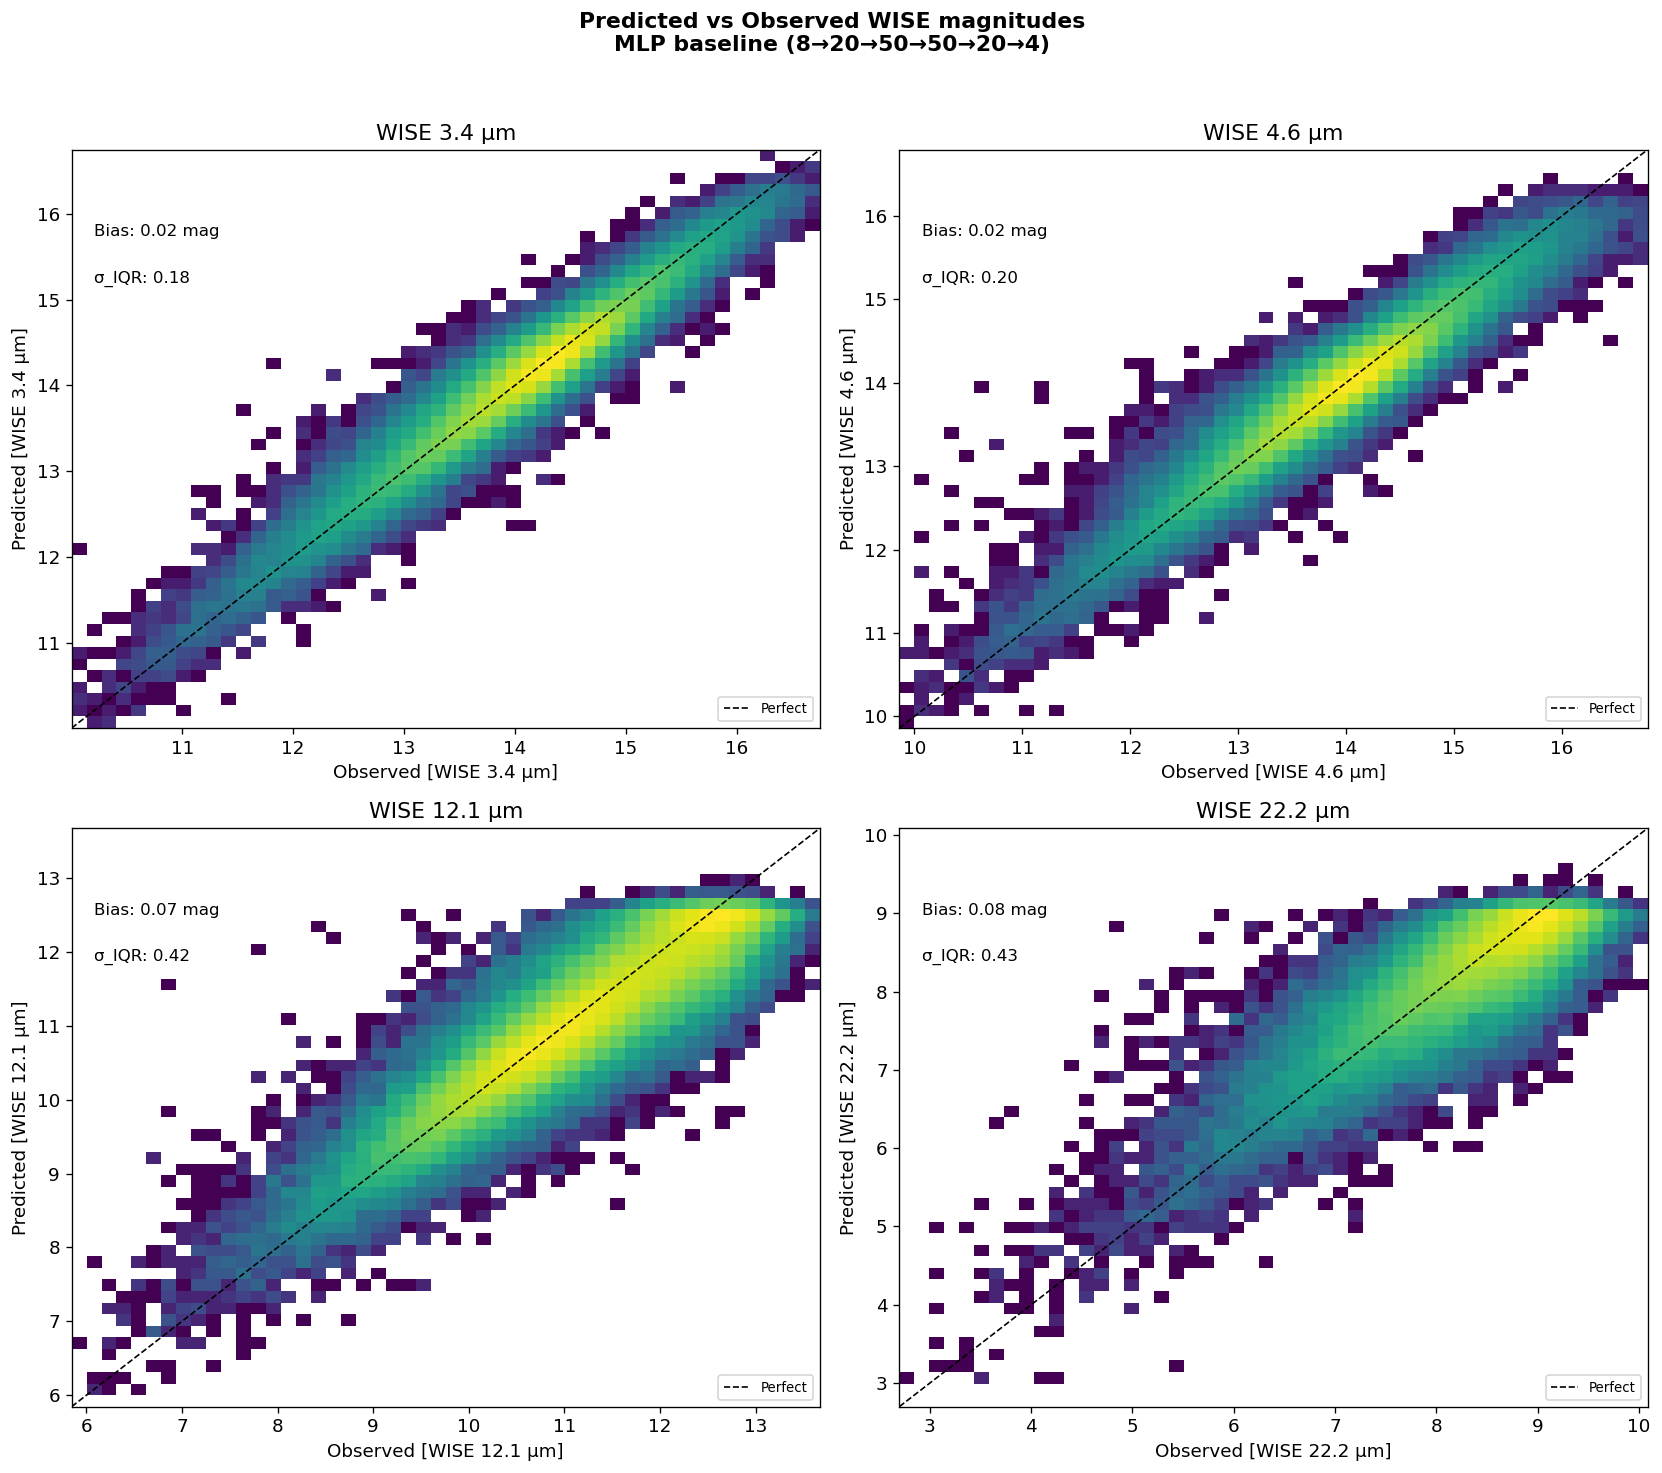

In [12]:
MODEL_ID = "mlp_baseline"
cache_pred = CACHE_DIR / f"{MODEL_ID}_preds.npy"

# Prefer loading from existing train_their_data.py results if split matches
if BASELINE_MATCHES and not FORCE_RETRAIN and not cache_pred.exists():
    print(f"[{MODEL_ID}] Split matches baseline — copying from {BASELINE_DIR}")
    bl = np.load(BASELINE_DIR / "test_results.npz")
    y_pred_baseline = bl["y_pred_mag"].astype(np.float32)
    np.save(cache_pred, y_pred_baseline)
    # Also copy weights
    import shutil
    wt_src = BASELINE_DIR / "mlp_weights.pt"
    if wt_src.exists():
        shutil.copy(wt_src, CACHE_DIR / f"{MODEL_ID}_weights.pt")
    print(f"  Cached {y_pred_baseline.shape}")
else:
    y_pred_baseline = train_mlp(
        X_tr_gpu, Y_tr_gpu, X_te_gpu, Y_te_gpu,
        hidden_layers=[20, 50, 50, 20], model_id=MODEL_ID
    )

ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_baseline, MODEL_ID, "MLP baseline (8→20→50→50→20→4)")
ALL_NAMES[MODEL_ID]   = "mlp_baseline"

### 5.2  mlp_wide  (8→128→128→128→4, ~34K params)

[mlp_wide] Training MLP hidden_layers=[128, 128, 128]  linear=False
  Parameters: 34,692
  ep=     0  val=252.5129  patience=0/1000  lr=4.00e-03  (0s)
  ep=  2000  val=0.4118  patience=75/1000  lr=4.00e-03  (36s)
  ep=  4000  val=0.2163  patience=31/1000  lr=4.00e-03  (71s)
  ep=  6000  val=0.1831  patience=30/1000  lr=4.00e-03  (106s)
  ep=  8000  val=0.1605  patience=17/1000  lr=4.00e-03  (142s)
  ep= 10000  val=0.2162  patience=10/1000  lr=4.00e-03  (177s)
  ep= 12000  val=0.1491  patience=1/1000  lr=4.00e-03  (213s)
  ep= 14000  val=0.1423  patience=0/1000  lr=4.00e-03  (248s)
  ep= 16000  val=0.1481  patience=25/1000  lr=4.00e-03  (284s)
  ep= 18000  val=0.1399  patience=4/1000  lr=4.00e-03  (319s)
  ep= 20000  val=0.1424  patience=84/1000  lr=4.00e-03  (354s)
  ep= 22000  val=0.1368  patience=0/1000  lr=2.00e-03  (390s)
  ep= 24000  val=0.1377  patience=56/1000  lr=2.00e-03  (425s)
  ep= 26000  val=0.1364  patience=2/1000  lr=1.00e-03  (461s)
  ep= 28000  val=0.1364  patience=198

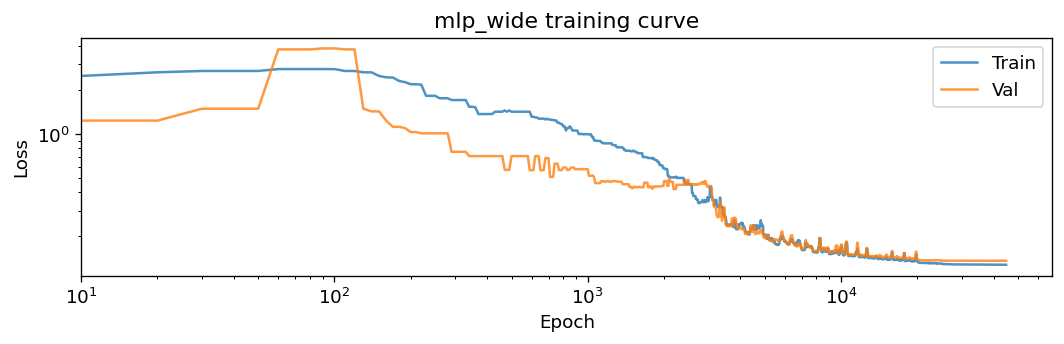

  Cached to ../results/model_comparison/cache

Model: MLP wide (8→128→128→128→4)
Band    chi2N_demo  chi2N_std   Paper  IQR_chi   <chi>      R2      Pr  f_out3s    N_det
-------------------------------------------------------------------------------------
W1           1.499     52.922    1.33    1.064   0.006   0.915   0.957   0.0253   152831
W2           1.330     38.618    1.17    0.946   0.004   0.891   0.944   0.0203   152806
W3           2.505     62.176    2.23    1.182   0.006   0.809   0.903   0.0519   111738
W4           1.651     34.056    1.41    0.863   0.011   0.688   0.835   0.0278    54169


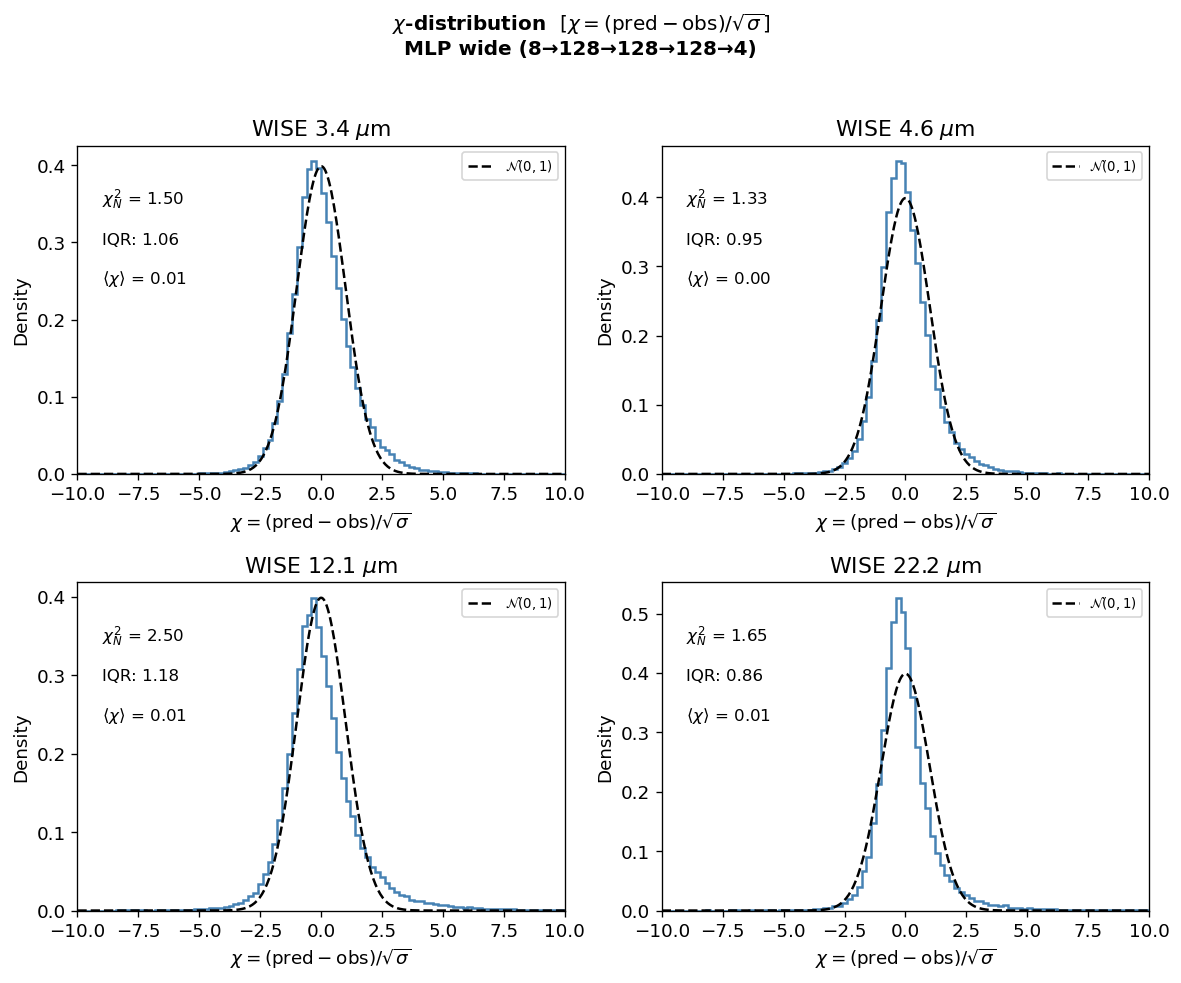

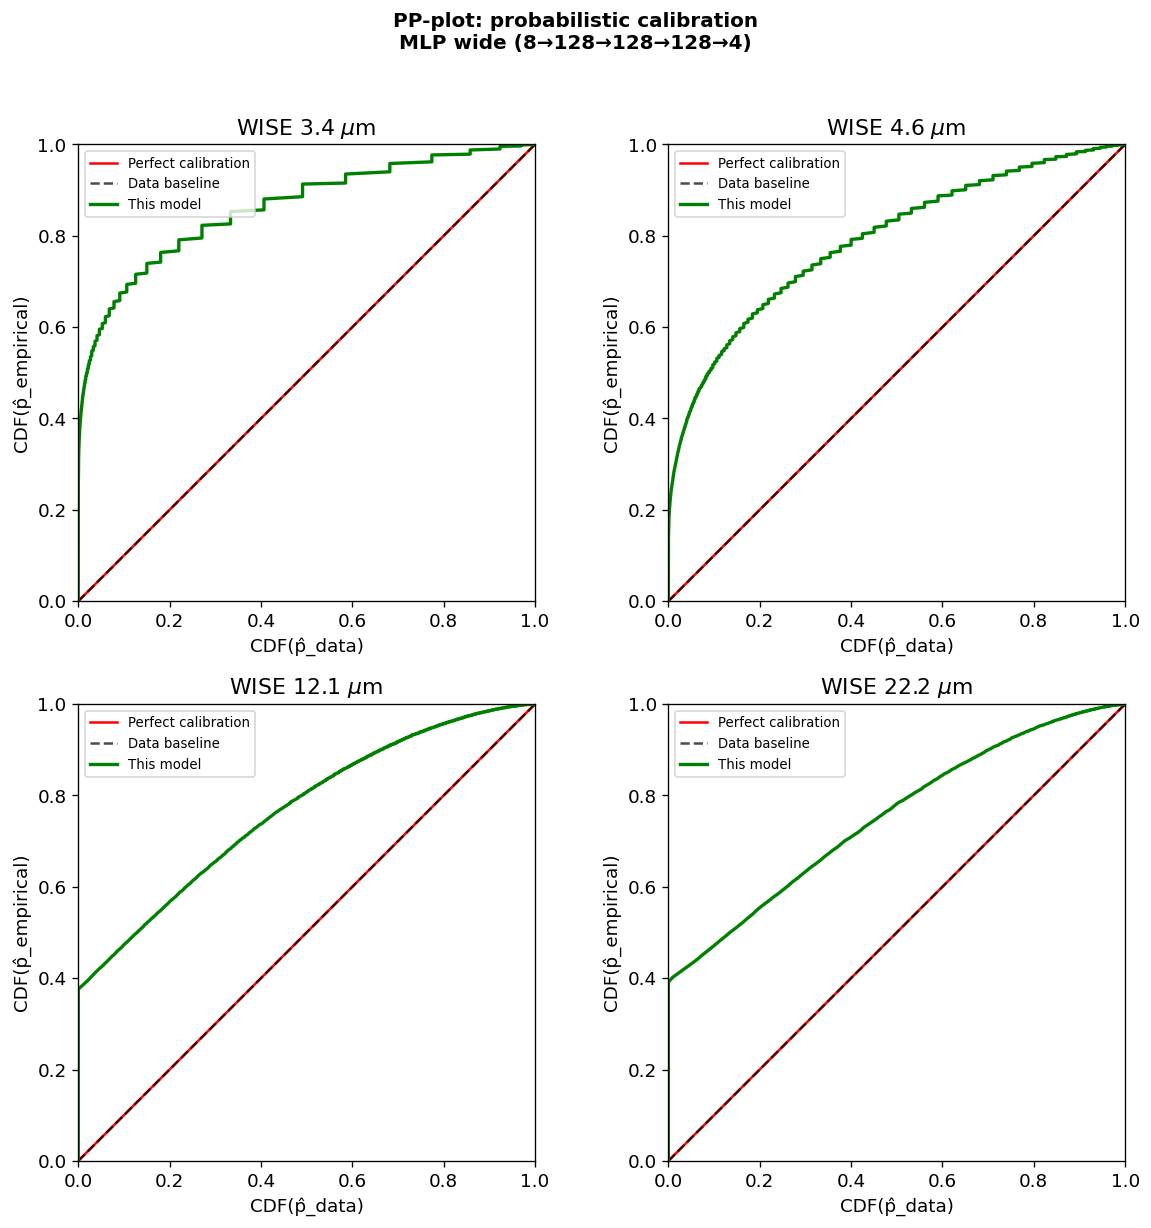

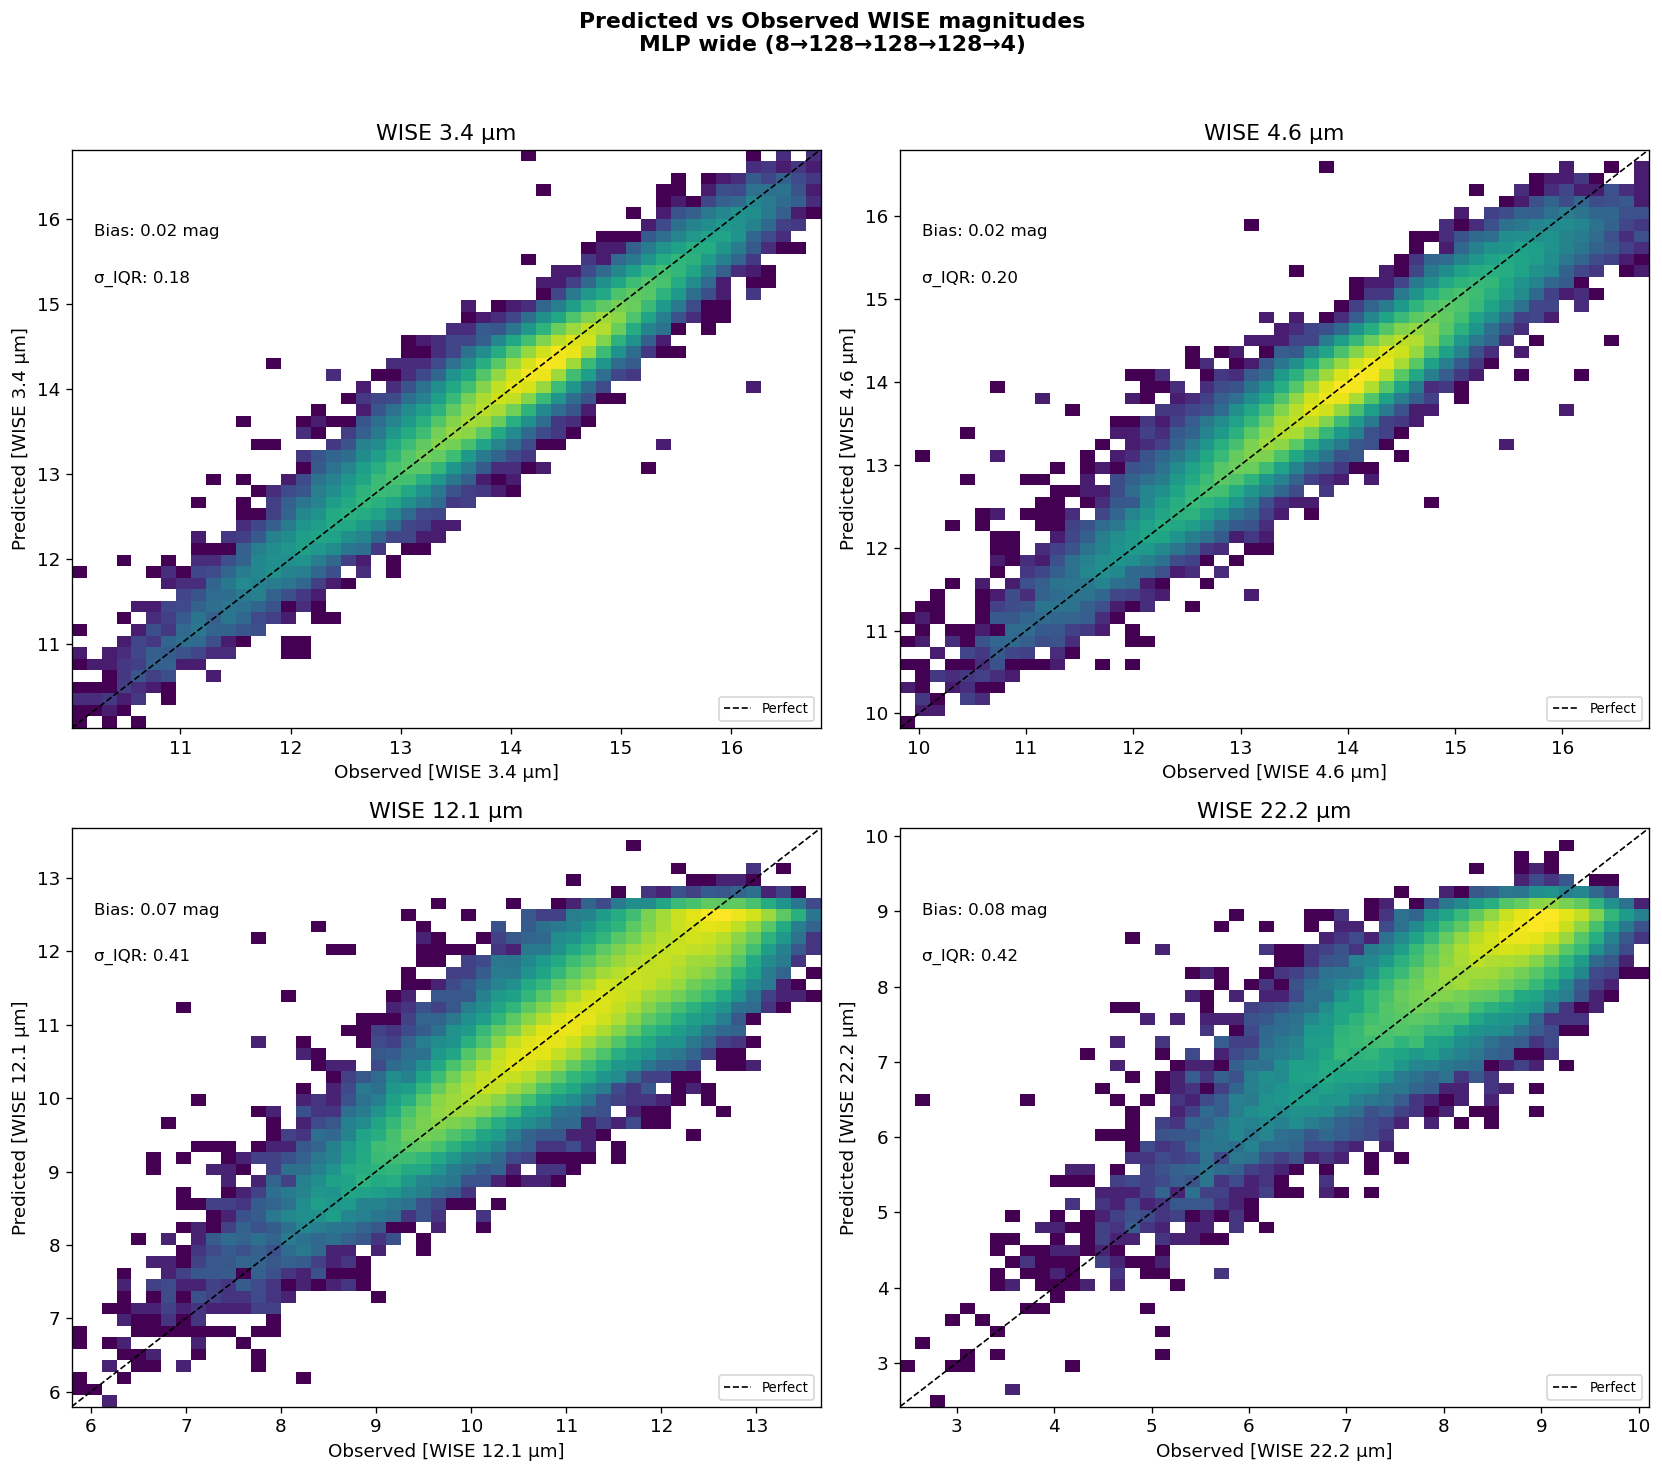

In [13]:
MODEL_ID = "mlp_wide"
y_pred_wide = train_mlp(
    X_tr_gpu, Y_tr_gpu, X_te_gpu, Y_te_gpu,
    hidden_layers=[128, 128, 128], model_id=MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_wide, MODEL_ID, "MLP wide (8→128→128→128→4)")
ALL_NAMES[MODEL_ID]   = "mlp_wide"

### 5.3  mlp_deep  (8→32→64→64→64→32→4, ~13K params)

In [14]:
MODEL_ID = "mlp_deep"
y_pred_deep = train_mlp(
    X_tr_gpu, Y_tr_gpu, X_te_gpu, Y_te_gpu,
    hidden_layers=[32, 64, 64, 64, 32], model_id=MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_deep, MODEL_ID, "MLP deep (8→32→64→64→64→32→4)")
ALL_NAMES[MODEL_ID]   = "mlp_deep"

[mlp_deep] Training MLP hidden_layers=[32, 64, 64, 64, 32]  linear=False
  Parameters: 12,932
  ep=     0  val=292.9799  patience=0/1000  lr=4.00e-03  (0s)
  ep=  2000  val=0.7610  patience=89/1000  lr=4.00e-03  (30s)
  ep=  4000  val=0.2186  patience=16/1000  lr=2.00e-03  (60s)
  ep=  6000  val=0.1672  patience=0/1000  lr=2.00e-03  (90s)
  ep=  8000  val=0.1774  patience=3/1000  lr=2.00e-03  (120s)
  ep= 10000  val=0.1579  patience=12/1000  lr=2.00e-03  (149s)
  ep= 12000  val=0.1588  patience=48/1000  lr=2.00e-03  (179s)
  ep= 14000  val=0.1483  patience=28/1000  lr=2.00e-03  (209s)
  ep= 16000  val=0.1669  patience=34/1000  lr=2.00e-03  (239s)
  ep= 18000  val=0.1430  patience=1/1000  lr=1.00e-03  (269s)
  ep= 20000  val=0.1415  patience=0/1000  lr=1.00e-03  (299s)
  ep= 22000  val=0.1409  patience=0/1000  lr=1.00e-03  (329s)
  ep= 24000  val=0.1400  patience=1/1000  lr=1.00e-03  (359s)
  ep= 26000  val=0.1399  patience=43/1000  lr=1.00e-03  (388s)
  ep= 28000  val=0.1393  patience=

KeyboardInterrupt: 

### 5.4  mlp_tiny  (8→20→20→4, 684 params)

In [ ]:
MODEL_ID = "mlp_tiny"
y_pred_tiny = train_mlp(
    X_tr_gpu, Y_tr_gpu, X_te_gpu, Y_te_gpu,
    hidden_layers=[20, 20], model_id=MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_tiny, MODEL_ID, "MLP tiny (8→20→20→4)")
ALL_NAMES[MODEL_ID]   = "mlp_tiny"

### 5.5  mlp_linear  (8→4, no hidden, no ReLU, 36 params)

In [ ]:
MODEL_ID = "mlp_linear"
y_pred_mlp_linear = train_mlp(
    X_tr_gpu, Y_tr_gpu, X_te_gpu, Y_te_gpu,
    hidden_layers=[], model_id=MODEL_ID, is_linear=True
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_mlp_linear, MODEL_ID, "MLP linear (8→4, pure linear)")
ALL_NAMES[MODEL_ID]   = "mlp_linear"

---
## Section 6: Tier 2 — Ensemble Trees

Tree models are scale-invariant; unscaled inputs are used.

### 6.1  rf_100  (RandomForest, 100 trees)

In [ ]:
MODEL_ID = "rf_100"
y_pred_rf100 = run_sklearn_model(
    RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED),
    X_tr, Y_mag_tr, X_te, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_rf100, MODEL_ID, "Random Forest (100 trees)")
ALL_NAMES[MODEL_ID]   = "rf_100"

### 6.2  rf_500  (RandomForest, 500 trees)

In [ ]:
MODEL_ID = "rf_500"
y_pred_rf500 = run_sklearn_model(
    RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=SEED),
    X_tr, Y_mag_tr, X_te, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_rf500, MODEL_ID, "Random Forest (500 trees)")
ALL_NAMES[MODEL_ID]   = "rf_500"

### 6.3  histgbr  (HistGradientBoosting, max_iter=300, max_depth=6)

In [ ]:
MODEL_ID = "histgbr"
y_pred_histgbr = run_sklearn_model(
    MultiOutputRegressor(
        HistGradientBoostingRegressor(max_iter=300, max_depth=6, random_state=SEED),
        n_jobs=4
    ),
    X_tr, Y_mag_tr, X_te, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_histgbr, MODEL_ID,
                                       "HistGradientBoosting (max_iter=300, depth=6)")
ALL_NAMES[MODEL_ID]   = "histgbr"

### 6.4  histgbr_shallow  (HistGradientBoosting, max_iter=100, max_depth=3)

In [ ]:
MODEL_ID = "histgbr_shallow"
y_pred_histgbr_sh = run_sklearn_model(
    MultiOutputRegressor(
        HistGradientBoostingRegressor(max_iter=100, max_depth=3, random_state=SEED),
        n_jobs=4
    ),
    X_tr, Y_mag_tr, X_te, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_histgbr_sh, MODEL_ID,
                                       "HistGradientBoosting shallow (iter=100, depth=3)")
ALL_NAMES[MODEL_ID]   = "histgbr_shallow"

---
## Section 7: Tier 3 — k-NN

Scaled inputs. May use a 20% training subsample if the full set is too slow.

In [ ]:
# Subsample for k-NN if dataset is very large (>200K training samples)
KNN_MAX_TRAIN = 200_000
if len(X_tr_sc) > KNN_MAX_TRAIN:
    np.random.seed(SEED)
    knn_idx = np.random.choice(len(X_tr_sc), KNN_MAX_TRAIN, replace=False)
    X_knn_tr = X_tr_sc[knn_idx]
    Y_knn_tr = Y_mag_tr[knn_idx]
    print(f"k-NN will train on {KNN_MAX_TRAIN:,} / {len(X_tr_sc):,} samples (subsampled)")
else:
    X_knn_tr = X_tr_sc
    Y_knn_tr = Y_mag_tr
    print(f"k-NN will train on full {len(X_tr_sc):,} training samples")

### 7.1  knn_10  (k=10, scaled inputs)

In [ ]:
MODEL_ID = "knn_10"
y_pred_knn10 = run_sklearn_model(
    KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    X_knn_tr, Y_knn_tr, X_te_sc, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_knn10, MODEL_ID, "k-NN (k=10, scaled)")
ALL_NAMES[MODEL_ID]   = "knn_10"

### 7.2  knn_50  (k=50, scaled inputs)

In [ ]:
MODEL_ID = "knn_50"
y_pred_knn50 = run_sklearn_model(
    KNeighborsRegressor(n_neighbors=50, n_jobs=-1),
    X_knn_tr, Y_knn_tr, X_te_sc, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_knn50, MODEL_ID, "k-NN (k=50, scaled)")
ALL_NAMES[MODEL_ID]   = "knn_50"

---
## Section 8: Tier 4 — Linear Models

Scaled inputs.

### 8.1  linear  (OLS multi-output)

In [ ]:
MODEL_ID = "linear"
y_pred_linear = run_sklearn_model(
    LinearRegression(),
    X_tr_sc, Y_mag_tr, X_te_sc, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_linear, MODEL_ID, "Linear Regression (OLS)")
ALL_NAMES[MODEL_ID]   = "linear"

### 8.2  ridge_cv  (RidgeCV, alpha in [0.01, 0.1, 1, 10, 100])

In [ ]:
MODEL_ID = "ridge_cv"
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
y_pred_ridge = run_sklearn_model(
    MultiOutputRegressor(RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]), n_jobs=4),
    X_tr_sc, Y_mag_tr, X_te_sc, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_ridge, MODEL_ID, "Ridge Regression (CV alpha)")
ALL_NAMES[MODEL_ID]   = "ridge_cv"

### 8.3  lasso  (Lasso, alpha=0.001)

In [ ]:
MODEL_ID = "lasso"
y_pred_lasso = run_sklearn_model(
    MultiOutputRegressor(Lasso(alpha=0.001, max_iter=2000), n_jobs=4),
    X_tr_sc, Y_mag_tr, X_te_sc, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_lasso, MODEL_ID, "Lasso (alpha=0.001)")
ALL_NAMES[MODEL_ID]   = "lasso"

---
## Section 9: Tier 5 — Baselines

### 9.1  decision_tree  (max_depth=8)

In [ ]:
MODEL_ID = "decision_tree"
y_pred_dt = run_sklearn_model(
    DecisionTreeRegressor(max_depth=8, random_state=SEED),
    X_tr, Y_mag_tr, X_te, MODEL_ID
)
ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_dt, MODEL_ID, "Decision Tree (max_depth=8)")
ALL_NAMES[MODEL_ID]   = "decision_tree"

### 9.2  mean_baseline  (predict training-set mean per band)

In [ ]:
MODEL_ID = "mean_baseline"
cache_pred = CACHE_DIR / f"{MODEL_ID}_preds.npy"

if not FORCE_RETRAIN and cache_pred.exists():
    y_pred_mean = np.load(cache_pred)
    print(f"[{MODEL_ID}] Loaded from cache.")
else:
    # Compute mean only over detected training galaxies per band
    det_tr = detected[idx_train]
    band_means = np.array([
        Y_mag_tr[det_tr[:, j], j].mean() for j in range(4)
    ], dtype=np.float32)
    print(f"Training-set mean magnitudes: {dict(zip(WISE_BANDS, band_means.round(3)))}")
    y_pred_mean = np.tile(band_means, (len(X_te), 1)).astype(np.float32)
    np.save(cache_pred, y_pred_mean)

ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_mean, MODEL_ID, "Mean baseline (predict train mean)")
ALL_NAMES[MODEL_ID]   = "mean_baseline"

### 9.3  median_baseline  (predict training-set median per band)

In [ ]:
MODEL_ID = "median_baseline"
cache_pred = CACHE_DIR / f"{MODEL_ID}_preds.npy"

if not FORCE_RETRAIN and cache_pred.exists():
    y_pred_median = np.load(cache_pred)
    print(f"[{MODEL_ID}] Loaded from cache.")
else:
    det_tr = detected[idx_train]
    band_medians = np.array([
        np.median(Y_mag_tr[det_tr[:, j], j]) for j in range(4)
    ], dtype=np.float32)
    print(f"Training-set median magnitudes: {dict(zip(WISE_BANDS, band_medians.round(3)))}")
    y_pred_median = np.tile(band_medians, (len(X_te), 1)).astype(np.float32)
    np.save(cache_pred, y_pred_median)

ALL_METRICS[MODEL_ID] = eval_and_plot(y_pred_median, MODEL_ID, "Median baseline (predict train median)")
ALL_NAMES[MODEL_ID]   = "median_baseline"

---
## Section 10: Summary Comparison

In [ ]:
# ─── Build summary DataFrame ─────────────────────────────────────────────────
rows = []
for model_id, metrics in ALL_METRICS.items():
    row = {"model_id": model_id, "model_name": ALL_NAMES.get(model_id, model_id)}
    chi2_vals = []
    r2_vals   = []
    for b in WISE_BANDS:
        m = metrics.get(b, {})
        for key in ["chi2n_demo", "chi2n_std", "iqr_chi", "mean_chi",
                    "r2", "pearson_r", "frac_outlier_3s", "n_det"]:
            row[f"{b}_{key}"] = m.get(key, np.nan)
        if "chi2n_demo" in m:
            chi2_vals.append(m["chi2n_demo"])
            r2_vals.append(m["r2"])
    row["mean_chi2n"] = np.mean(chi2_vals) if chi2_vals else np.nan
    row["mean_r2"]    = np.mean(r2_vals)   if r2_vals   else np.nan
    rows.append(row)

df_summary = pd.DataFrame(rows).sort_values("mean_chi2n").reset_index(drop=True)
df_summary.to_csv(OUT_DIR / "summary_table.csv", index=False)
print(f"Saved summary to {OUT_DIR / 'summary_table.csv'}")

# ─── Print compact leaderboard ───────────────────────────────────────────────
print(f"\n{'Rank':<5s} {'Model':<20s} {'mean_chi2N':>11s}  ", end="")
for b in WISE_BANDS:
    print(f"{b}_chi2N:>9s  ".format(**{}), end="")
print(f"{'mean_R2':>9s}")
print(f"{'Rank':<5s} {'Model':<20s} {'mean_chi2N':>11s}  "
      + "  ".join([f"{b}_chi2N" for b in WISE_BANDS]) + f"  {'mean_R2':>9s}")
print("-" * 90)
for i, row in df_summary.iterrows():
    chi_parts = "  ".join([f"{row.get(f'{b}_chi2n_demo', np.nan):>9.3f}" for b in WISE_BANDS])
    print(f"{i+1:<5d} {row['model_name']:<20s} {row['mean_chi2n']:>11.3f}  {chi_parts}  {row['mean_r2']:>9.3f}")

print(f"\nPaper targets: ", end="")
print("  ".join([f"{b}={PAPER_CHI2[b]}" for b in WISE_BANDS]))

In [ ]:
# ─── Bar chart: chi²_N per model per band ────────────────────────────────────
n_models = len(df_summary)
x        = np.arange(n_models)
width    = 0.18
colors   = ["steelblue", "darkorange", "seagreen", "tomato"]

fig, ax = plt.subplots(figsize=(max(12, n_models * 0.8), 5))
for j, (b, c) in enumerate(zip(WISE_BANDS, colors)):
    vals = [row.get(f"{b}_chi2n_demo", np.nan) for _, row in df_summary.iterrows()]
    ax.bar(x + (j - 1.5) * width, vals, width, label=b, color=c, alpha=0.8)

for b, c in zip(WISE_BANDS, colors):
    ax.axhline(PAPER_CHI2[b], color=c, ls="--", lw=1.2, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(df_summary["model_name"].tolist(), rotation=40, ha="right", fontsize=9)
ax.set(ylabel=r"$\chi^2_N$", title=r"$\chi^2_N$ per model per band  (dashed = paper target)")
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_chi2.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved comparison_chi2.png")

In [ ]:
# ─── Bar chart: R² per model per band ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, n_models * 0.8), 5))
for j, (b, c) in enumerate(zip(WISE_BANDS, colors)):
    vals = [row.get(f"{b}_r2", np.nan) for _, row in df_summary.iterrows()]
    ax.bar(x + (j - 1.5) * width, vals, width, label=b, color=c, alpha=0.8)

ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(df_summary["model_name"].tolist(), rotation=40, ha="right", fontsize=9)
ax.set(ylabel=r"$R^2$", title=r"$R^2$ per model per band")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_r2.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved comparison_r2.png")

---
## Section 11: Top-3 Models Deep Dive

Overlay chi-distributions and PP-plots for the three best-performing models.

In [ ]:
# Identify top-3 by mean chi²_N
top3_ids   = df_summary["model_id"].iloc[:3].tolist()
top3_names = df_summary["model_name"].iloc[:3].tolist()
print("Top-3 models (by mean chi²_N):")
for i, (mid, mn) in enumerate(zip(top3_ids, top3_names)):
    print(f"  {i+1}. {mn}  (chi²_N = {df_summary.loc[df_summary.model_id==mid, 'mean_chi2n'].values[0]:.3f})")

# Load their predictions
top3_preds = {mid: np.load(CACHE_DIR / f"{mid}_preds.npy") for mid in top3_ids}

In [ ]:
# ─── Overlay chi distributions per band ──────────────────────────────────────
line_styles = ["-", "--", ":"]
overlay_colors = ["steelblue", "darkorange", "seagreen"]

for j, b in enumerate(WISE_BANDS):
    fig, ax = plt.subplots(figsize=(7, 4))
    x_ = np.linspace(-10, 10, 400)
    ax.plot(x_, scipy_norm.pdf(x_), "k--", lw=1.5, label=r"$\mathcal{N}(0,1)$", alpha=0.6)

    for mid, mn, ls, c in zip(top3_ids, top3_names, line_styles, overlay_colors):
        y_pred = top3_preds[mid]
        mask   = det_te[:, j] & (Y_sigma_raw_te[:, j] < NONDET_THR)
        if mask.sum() < 5:
            continue
        resid  = y_pred[mask, j] - Y_mag_te[mask, j]
        chi    = resid / np.sqrt(Y_sigma_raw_te[mask, j])
        chi2n  = np.mean(chi**2)
        ax.hist(chi, bins=100, range=(-10, 10), histtype="step",
                density=True, color=c, linestyle=ls, linewidth=1.8,
                label=f"{mn}  (χ²_N={chi2n:.2f})")

    ax.set(xlim=(-10, 10),
           xlabel=r"$\chi = (\mathrm{pred}-\mathrm{obs})/\sqrt{\sigma}$",
           ylabel="Density", title=f"{WISE_LABELS[b]}  — top-3 models")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"band_chi_overlay_{b}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"Saved band_chi_overlay_{b}.png")

In [ ]:
# ─── Overlay PP-plots per band ────────────────────────────────────────────────
for j, b in enumerate(WISE_BANDS):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], "r-", lw=1.5, label="Perfect")

    # Compute data baseline once for this band
    mask = det_te[:, j] & (Y_sigma_raw_te[:, j] < NONDET_THR)
    if mask.sum() < 5:
        plt.close(); continue
    sigma_b = np.sqrt(Y_sigma_raw_te[mask, j])
    pd_base = np.sort(scipy_norm.pdf(0, loc=0, scale=sigma_b))
    thresh  = np.linspace(0, pd_base.max(), 1000)
    cdf_d   = np.searchsorted(pd_base, thresh) / len(pd_base)
    ax.plot(cdf_d, cdf_d, "k--", lw=1.5, alpha=0.6, label="Data baseline")

    for mid, mn, ls, c in zip(top3_ids, top3_names, line_styles, overlay_colors):
        y_pred = top3_preds[mid]
        pe     = np.sort(scipy_norm.pdf(y_pred[mask, j], loc=Y_mag_te[mask, j], scale=sigma_b))
        cdf_e  = np.searchsorted(pe, thresh) / len(pe)
        ax.plot(cdf_d, cdf_e, color=c, ls=ls, lw=2, label=mn)

    ax.set(xlabel="CDF(p̂_data)", ylabel="CDF(p̂_empirical)",
           title=f"{WISE_LABELS[b]}  — top-3 PP-plot",
           xlim=(0, 1), ylim=(0, 1), aspect="equal")
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"band_ppplot_overlay_{b}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"Saved band_ppplot_overlay_{b}.png")

In [ ]:
# ─── Final summary printout ──────────────────────────────────────────────────
print("=" * 70)
print("FINAL LEADERBOARD  (sorted by mean chi²_N, lower is better)")
print("=" * 70)

cols = ["model_name", "mean_chi2n", "mean_r2"] + \
       [f"{b}_chi2n_demo" for b in WISE_BANDS] + \
       [f"{b}_r2" for b in WISE_BANDS]
with pd.option_context("display.float_format", "{:.3f}".format,
                        "display.max_columns", 20,
                        "display.width", 140):
    print(df_summary[cols].to_string(index=False))

print(f"\nPaper chi²_N targets:")
for b in WISE_BANDS:
    print(f"  {b}: {PAPER_CHI2[b]}")

# Sanity checks
print("\n--- Sanity checks ---")
for mid in ["mean_baseline", "median_baseline"]:
    if mid in ALL_METRICS:
        mean_chi2 = df_summary.loc[df_summary.model_id == mid, "mean_chi2n"].values
        if len(mean_chi2):
            ok = mean_chi2[0] > 10
            print(f"  {mid}: mean_chi2N={mean_chi2[0]:.1f}  [>10 expected: {'PASS' if ok else 'FAIL'}]")

if "mlp_linear" in ALL_METRICS and "linear" in ALL_METRICS:
    c_mlp = df_summary.loc[df_summary.model_id == "mlp_linear", "mean_chi2n"].values[0]
    c_ols = df_summary.loc[df_summary.model_id == "linear",     "mean_chi2n"].values[0]
    ratio = c_mlp / c_ols if c_ols > 0 else np.nan
    ok    = ratio < 1.2
    print(f"  mlp_linear/linear chi2N ratio={ratio:.3f}  [<1.2 expected: {'PASS' if ok else 'WARN'}]")

if "mlp_baseline" in ALL_METRICS:
    c_bl = df_summary.loc[df_summary.model_id == "mlp_baseline", "mean_chi2n"].values[0]
    print(f"\n  mlp_baseline mean_chi2N={c_bl:.3f}")
    print(f"  Expected ~{np.mean(list(PAPER_CHI2.values())):.2f} (paper) or slightly above")

print(f"\nAll outputs in: {OUT_DIR}")
print("Done.")